In [1]:
# Sujay V
# 24BTRAO041

# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Step 2: Load the house price dataset

data = pd.read_csv(r"C:\Users\Sujay\OneDrive\Documents\GitHub\Tensorflow-house-price-prediction\house_prices.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset Shape: (300, 6)


,area,bedrooms,bathrooms,stories,age,price
0,3674,4,3,2,16,842100
1,1360,1,1,2,27,300000
2,1794,1,1,2,25,329000
3,1630,2,3,1,8,478500
4,1595,1,1,2,21,300000


In [3]:
# Step 3: Display the structure, data types and number of non-null values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       300 non-null    int64
 1   bedrooms   300 non-null    int64
 2   bathrooms  300 non-null    int64
 3   stories    300 non-null    int64
 4   age        300 non-null    int64
 5   price      300 non-null    int64
dtypes: int64(6)
memory usage: 14.2 KB


In [4]:
# Step 4: Check whether the dataset contains any missing or null values

print("Missing Values in Each Column:")
print(data.isnull().sum())

Missing Values in Each Column:
area         0
bedrooms     0
bathrooms    0
stories      0
age          0
price        0
dtype: int64


In [5]:
# Step 5: Separate the input features from the target variable

X = data.drop("price", axis=1)
y = data["price"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("price")

Input Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'age']

Target Variable:
price


In [6]:
# Step 6: Split the dataset into 80% training data and 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (240, 5)
Testing Data: (60, 5)


In [7]:
# Step 7: Scale the input features using StandardScaler

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

print("Input features scaled successfully!")

Input features scaled successfully!


In [8]:
# Step 8: Scale the target variable for better neural network training

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).flatten()

print("Target variable scaled successfully!")

Target variable scaled successfully!


In [9]:
# Step 9: Build the regression model using TensorFlow Keras

model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 10: Compile the model using Adam optimizer, MSE loss and MAE metric

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
# Step 11: Train the model using the training dataset

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    verbose=0
)

print("Model training completed successfully!")

Model training completed successfully!


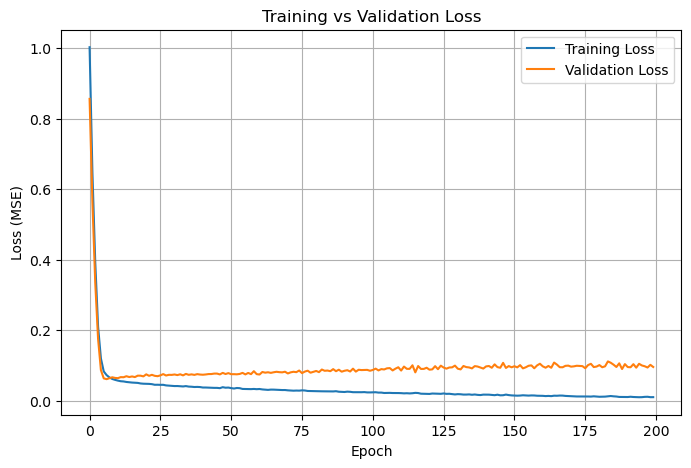

In [12]:
# Step 12: Plot training loss and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Step 13: Evaluate the trained model on the test data

test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test_scaled,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 0.10652092099189758
Test MAE: 0.2667303681373596


In [14]:
# Step 14: Generate predictions for the test dataset

predictions_scaled = model.predict(
    X_test_scaled,
    verbose=0
)

# Convert predictions back to original price scale
predictions = y_scaler.inverse_transform(
    predictions_scaled
).flatten()

print("Predictions generated successfully!")

Predictions generated successfully!


In [15]:
# Step 15: Calculate MSE, MAE, RMSE and R2 score

mse = mean_squared_error(
    y_test,
    predictions
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("Model Evaluation Results:")
print("Mean Squared Error (MSE):", round(mse, 2))
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Model Evaluation Results:
Mean Squared Error (MSE): 3089432064.0
Mean Absolute Error (MAE): 45424.94
Root Mean Squared Error (RMSE): 55582.66
R2 Score: 0.887


In [16]:
# Step 16: Compare actual and predicted house prices

comparison = pd.DataFrame({
    "Actual Price": y_test.to_numpy(),
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,369300,446113.59375
1,386500,418813.28125
2,497000,476998.40625
3,380500,409949.75000
4,813900,829488.62500
5,474100,496420.37500
6,766000,657076.93750
7,537600,608630.31250
8,765000,732852.31250
9,603800,612197.25000


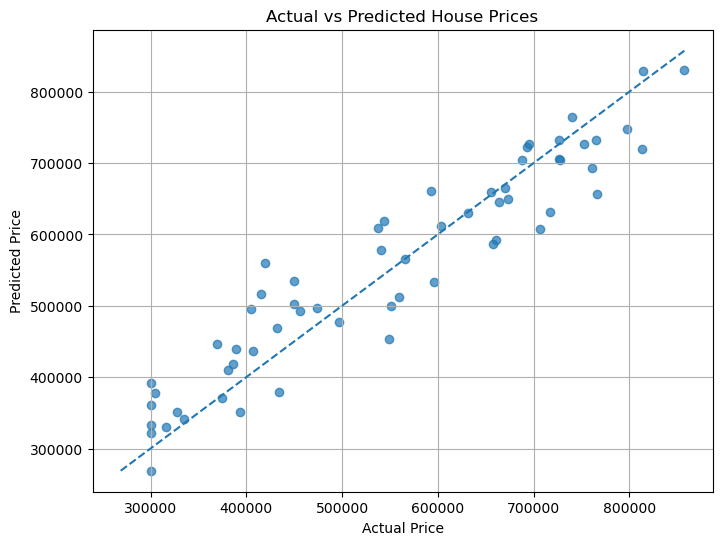

In [17]:
# Step 17: Visualize actual prices against predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

min_price = min(y_test.min(), predictions.min())
max_price = max(y_test.max(), predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

In [18]:
# Step 18: Display the first 10 actual and predicted prices

print("First 10 Predictions:")

for actual, predicted in zip(
    y_test.to_numpy()[:10],
    predictions[:10]
):
    print(
        f"Actual: {actual:.2f} | Predicted: {predicted:.2f}"
    )

First 10 Predictions:
Actual: 369300.00 | Predicted: 446113.59
Actual: 386500.00 | Predicted: 418813.28
Actual: 497000.00 | Predicted: 476998.41
Actual: 380500.00 | Predicted: 409949.75
Actual: 813900.00 | Predicted: 829488.62
Actual: 474100.00 | Predicted: 496420.38
Actual: 766000.00 | Predicted: 657076.94
Actual: 537600.00 | Predicted: 608630.31
Actual: 765000.00 | Predicted: 732852.31
Actual: 603800.00 | Predicted: 612197.25
